In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv("YouTube_Content_Review_Data.csv")

# Display the first 5 rows
df.head()

,Employee_ID,Employee_Name,Team,Role,Week_Number,Week_Start_Date,Working_Days,Present_Days,Absent_Days,Leave_Days,...,Target_Cases,Productivity_Percent,Quality_Percent,Accuracy_Percent,Errors,Adherence_Percent,Overtime_Hours,Overall_Score,Performance_Status,Unnamed: 20
0,EMP001,Employee 001,Team A,Content Reviewer,1,05-01-2026,5,3,1,1,...,450,107%,95%,93%,24,95%,1,100%,Met Target,NaN
1,EMP001,Employee 001,Team A,Content Reviewer,2,12-01-2026,5,3,2,0,...,450,78%,91%,98%,32,94%,2,88%,Below Target,NaN
2,EMP001,Employee 001,Team A,Content Reviewer,3,19-01-2026,5,3,0,2,...,450,118%,92%,97%,42,99%,10,104%,Exceeded Target,NaN
3,EMP001,Employee 001,Team A,Content Reviewer,4,26-01-2026,5,4,1,0,...,450,118%,96%,100%,21,96%,2,106%,Exceeded Target,NaN
4,EMP001,Employee 001,Team A,Content Reviewer,5,02-02-2026,5,4,1,0,...,450,84%,96%,99%,15,91%,6,91%,Met Target,NaN


In [4]:
# Check number of rows and columns
print("Dataset shape:", df.shape)

# Show all column names
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (1200, 21)

Column names:
['Employee_ID', 'Employee_Name', 'Team', 'Role', 'Week_Number', 'Week_Start_Date', 'Working_Days', 'Present_Days', 'Absent_Days', 'Leave_Days', 'Cases_Reviewed', 'Target_Cases', 'Productivity_Percent', 'Quality_Percent', 'Accuracy_Percent', 'Errors', 'Adherence_Percent', 'Overtime_Hours', 'Overall_Score', 'Performance_Status', 'Unnamed: 20']


In [5]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Employee_ID           1200 non-null   object 
 1   Employee_Name         1200 non-null   object 
 2   Team                  1200 non-null   object 
 3   Role                  1200 non-null   object 
 4   Week_Number           1200 non-null   int64  
 5   Week_Start_Date       1200 non-null   object 
 6   Working_Days          1200 non-null   int64  
 7   Present_Days          1200 non-null   int64  
 8   Absent_Days           1200 non-null   int64  
 9   Leave_Days            1200 non-null   int64  
 10  Cases_Reviewed        1200 non-null   int64  
 11  Target_Cases          1200 non-null   int64  
 12  Productivity_Percent  1200 non-null   object 
 13  Quality_Percent       1200 non-null   object 
 14  Accuracy_Percent      1200 non-null   object 
 15  Errors               

In [6]:
# Check missing values in each column
df.isnull().sum()


,0
Employee_ID,0
Employee_Name,0
Team,0
Role,0
Week_Number,0
Week_Start_Date,0
Working_Days,0
Present_Days,0
Absent_Days,0
Leave_Days,0


In [7]:
# Check missing values in each column
df.isnull().sum()

,0
Employee_ID,0
Employee_Name,0
Team,0
Role,0
Week_Number,0
Week_Start_Date,0
Working_Days,0
Present_Days,0
Absent_Days,0
Leave_Days,0


In [8]:
# Remove the unwanted column
df = df.drop(columns=["Unnamed: 20"])

# Check the shape
print(df.shape)

(1200, 20)


In [9]:
# Percentage columns
percentage_columns = [
    "Productivity_Percent",
    "Quality_Percent",
    "Accuracy_Percent",
    "Adherence_Percent",
    "Overall_Score"
]

# Remove % symbol and convert to numeric
for col in percentage_columns:
    df[col] = df[col].str.replace("%", "").astype(float)

# Check the result
df[percentage_columns].head()

,Productivity_Percent,Quality_Percent,Accuracy_Percent,Adherence_Percent,Overall_Score
0,107.0,95.0,93.0,95.0,100.0
1,78.0,91.0,98.0,94.0,88.0
2,118.0,92.0,97.0,99.0,104.0
3,118.0,96.0,100.0,96.0,106.0
4,84.0,96.0,99.0,91.0,91.0


In [10]:
df["Week_Start_Date"] = pd.to_datetime(
    df["Week_Start_Date"],
    format="%d-%m-%Y"
)

df[["Week_Number", "Week_Start_Date"]].head()

,Week_Number,Week_Start_Date
0,1,2026-01-05
1,2,2026-01-12
2,3,2026-01-19
3,4,2026-01-26
4,5,2026-02-02


In [11]:
df.dtypes

,0
Employee_ID,object
Employee_Name,object
Team,object
Role,object
Week_Number,int64
Week_Start_Date,datetime64[ns]
Working_Days,int64
Present_Days,int64
Absent_Days,int64
Leave_Days,int64


In [13]:
# Calculate overall KPIs

print("Average Productivity:", round(df["Productivity_Percent"].mean(), 2), "%")
print("Average Quality:", round(df["Quality_Percent"].mean(), 2), "%")
print("Average Accuracy:", round(df["Accuracy_Percent"].mean(), 2), "%")
print("Average Adherence:", round(df["Adherence_Percent"].mean(), 2), "%")
print("Average Overall Score:", round(df["Overall_Score"].mean(), 2), "%")

print("Total Cases Reviewed:", df["Cases_Reviewed"].sum())
print("Total Target Cases:", df["Target_Cases"].sum())
print("Total Errors:", df["Errors"].sum())
print("Total Overtime Hours:", df["Overtime_Hours"].sum())

Average Productivity: 100.79 %
Average Quality: 92.41 %
Average Accuracy: 93.93 %
Average Adherence: 94.97 %
Average Overall Score: 96.35 %
Total Cases Reviewed: 544281
Total Target Cases: 540000
Total Errors: 41420
Total Overtime Hours: 6019


In [14]:
# Count each performance status

status_counts = df["Performance_Status"].value_counts()

print(status_counts)

Performance_Status
Met Target         640
Exceeded Target    366
Below Target       194
Name: count, dtype: int64


In [15]:
# Calculate percentage distribution

status_percentage = (
    df["Performance_Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(status_percentage)

Performance_Status
Met Target         53.33
Exceeded Target    30.50
Below Target       16.17
Name: proportion, dtype: float64


In [16]:
team_performance = df.groupby("Team").agg(
    Average_Productivity=("Productivity_Percent", "mean"),
    Average_Quality=("Quality_Percent", "mean"),
    Average_Accuracy=("Accuracy_Percent", "mean"),
    Average_Adherence=("Adherence_Percent", "mean"),
    Average_Overall_Score=("Overall_Score", "mean"),
    Total_Cases=("Cases_Reviewed", "sum"),
    Total_Errors=("Errors", "sum"),
    Total_Overtime=("Overtime_Hours", "sum")
).round(2)

team_performance

,Average_Productivity,Average_Quality,Average_Accuracy,Average_Adherence,Average_Overall_Score,Total_Cases,Total_Errors,Total_Overtime
Team,,,,,,,,
Team A,100.12,91.92,93.85,94.88,95.88,108141,8818,1232
Team B,100.71,92.76,93.91,95.22,96.46,108778,7852,1213
Team C,100.49,93.08,94.10,94.76,96.45,108534,7554,1201
Team D,101.68,92.25,93.66,94.80,96.58,109812,8561,1203
Team E,100.95,92.03,94.14,95.21,96.37,109016,8635,1170


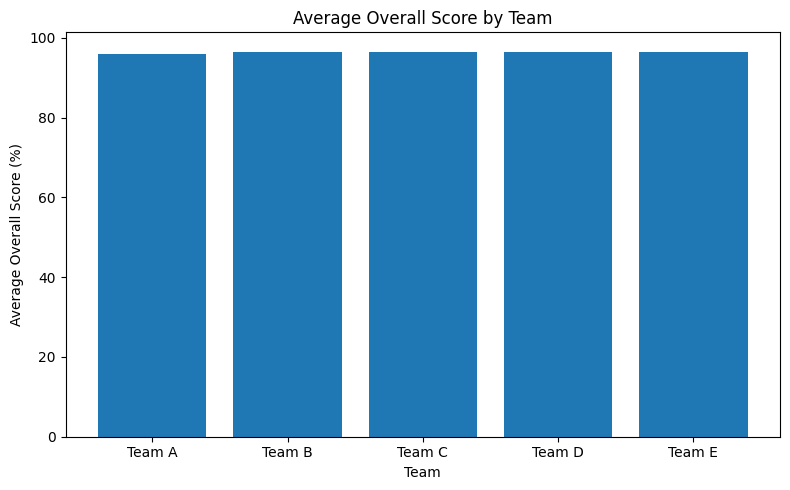

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    team_performance.index,
    team_performance["Average_Overall_Score"]
)

plt.title("Average Overall Score by Team")
plt.xlabel("Team")
plt.ylabel("Average Overall Score (%)")

plt.tight_layout()
plt.show()

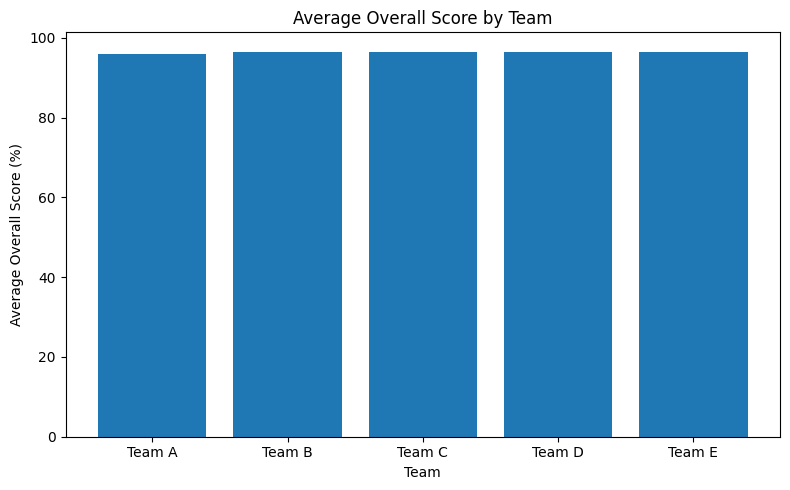

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    team_performance.index,
    team_performance["Average_Overall_Score"]
)

plt.title("Average Overall Score by Team")
plt.xlabel("Team")
plt.ylabel("Average Overall Score (%)")

plt.tight_layout()

# Save chart as an image
plt.savefig("team_overall_score.png", dpi=300, bbox_inches="tight")

plt.show()

In [19]:
# Compare productivity, quality and errors by team

team_analysis = df.groupby("Team").agg(
    Average_Productivity=("Productivity_Percent", "mean"),
    Average_Quality=("Quality_Percent", "mean"),
    Average_Accuracy=("Accuracy_Percent", "mean"),
    Total_Cases=("Cases_Reviewed", "sum"),
    Total_Errors=("Errors", "sum")
).round(2)

# Calculate error rate
team_analysis["Error_Rate_Percent"] = (
    team_analysis["Total_Errors"] /
    team_analysis["Total_Cases"] * 100
).round(2)

team_analysis

,Average_Productivity,Average_Quality,Average_Accuracy,Total_Cases,Total_Errors,Error_Rate_Percent
Team,,,,,,
Team A,100.12,91.92,93.85,108141,8818,8.15
Team B,100.71,92.76,93.91,108778,7852,7.22
Team C,100.49,93.08,94.10,108534,7554,6.96
Team D,101.68,92.25,93.66,109812,8561,7.80
Team E,100.95,92.03,94.14,109016,8635,7.92


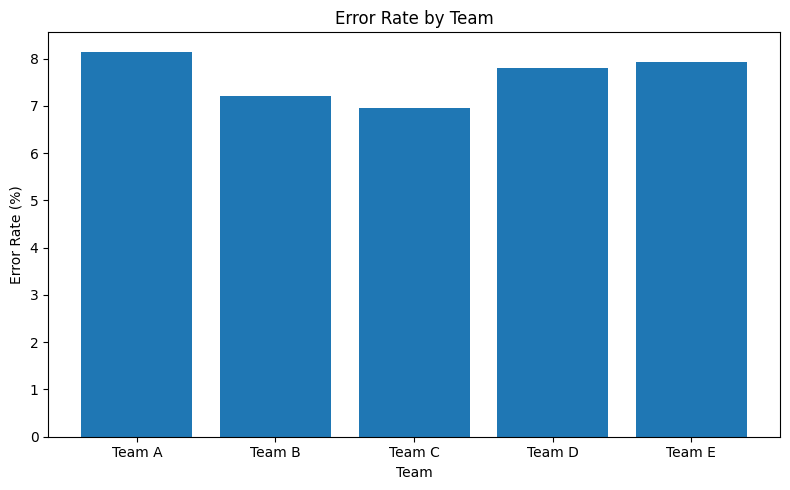

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    team_analysis.index,
    team_analysis["Error_Rate_Percent"]
)

plt.title("Error Rate by Team")
plt.xlabel("Team")
plt.ylabel("Error Rate (%)")

plt.tight_layout()

plt.savefig("team_error_rate.png", dpi=300, bbox_inches="tight")

plt.show()

In [21]:
# Weekly performance analysis

weekly_performance = df.groupby("Week_Number").agg(
    Average_Productivity=("Productivity_Percent", "mean"),
    Average_Quality=("Quality_Percent", "mean"),
    Average_Accuracy=("Accuracy_Percent", "mean"),
    Average_Adherence=("Adherence_Percent", "mean"),
    Average_Overall_Score=("Overall_Score", "mean"),
    Total_Cases=("Cases_Reviewed", "sum"),
    Total_Errors=("Errors", "sum")
).round(2)

weekly_performance

,Average_Productivity,Average_Quality,Average_Accuracy,Average_Adherence,Average_Overall_Score,Total_Cases,Total_Errors
Week_Number,,,,,,,
1,98.51,92.22,93.72,95.45,95.34,44335,3478
2,100.71,93.34,93.88,95.42,96.65,45322,3026
3,102.65,91.87,94.51,94.61,97.02,46202,3832
4,99.21,92.22,94.24,94.54,95.64,44630,3478
5,101.57,92.70,93.82,94.93,96.74,45736,3344
6,100.82,91.96,93.75,95.13,96.18,45374,3657
7,100.83,93.16,94.10,95.08,96.67,45385,3067
8,100.57,92.85,93.48,94.51,96.25,45279,3246
9,102.23,91.64,93.98,94.91,96.68,45986,3859


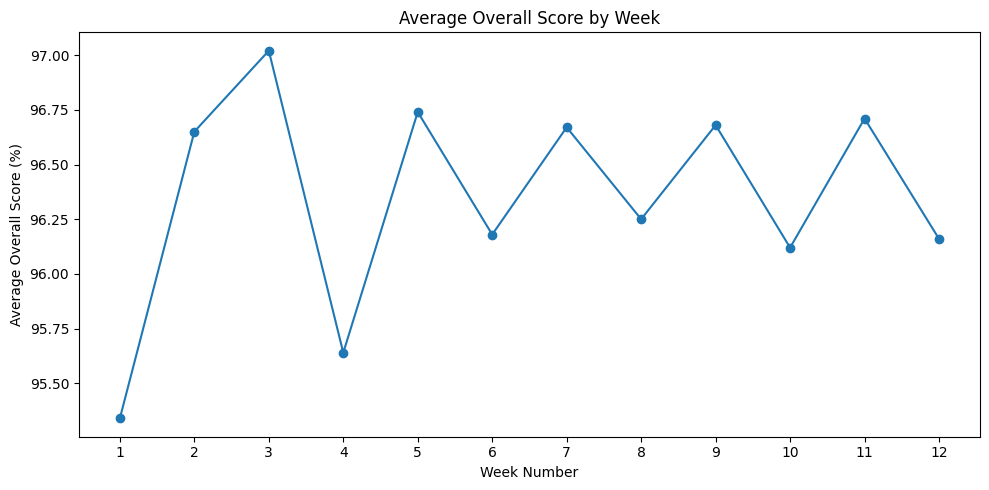

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    weekly_performance.index,
    weekly_performance["Average_Overall_Score"],
    marker="o"
)

plt.title("Average Overall Score by Week")
plt.xlabel("Week Number")
plt.ylabel("Average Overall Score (%)")

plt.xticks(weekly_performance.index)

plt.tight_layout()

plt.savefig(
    "weekly_overall_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# Calculate correlation between productivity and quality

productivity_quality_corr = df[
    ["Productivity_Percent", "Quality_Percent"]
].corr()

productivity_quality_corr

,Productivity_Percent,Quality_Percent
Productivity_Percent,1.000000,-0.021562
Quality_Percent,-0.021562,1.000000


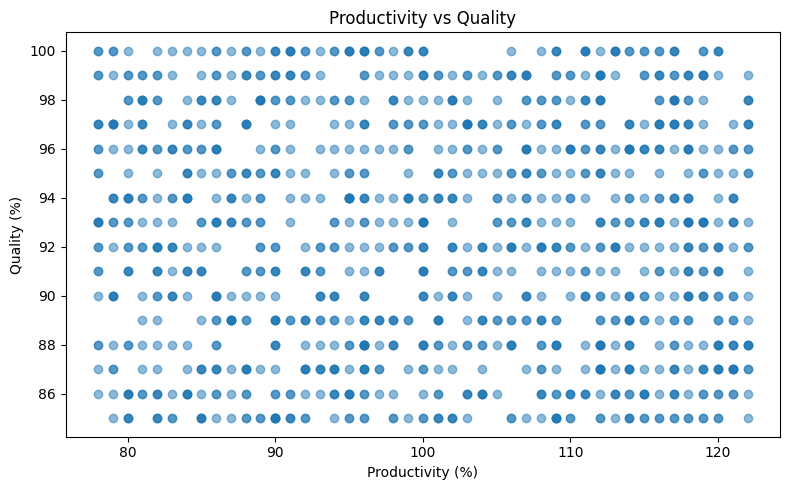

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Productivity_Percent"],
    df["Quality_Percent"],
    alpha=0.5
)

plt.title("Productivity vs Quality")
plt.xlabel("Productivity (%)")
plt.ylabel("Quality (%)")

plt.tight_layout()

plt.savefig(
    "productivity_vs_quality.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [25]:
# Correlation analysis for key performance metrics

correlation_matrix = df[
    [
        "Productivity_Percent",
        "Quality_Percent",
        "Accuracy_Percent",
        "Adherence_Percent",
        "Overall_Score"
    ]
].corr().round(2)

correlation_matrix

,Productivity_Percent,Quality_Percent,Accuracy_Percent,Adherence_Percent,Overall_Score
Productivity_Percent,1.00,-0.02,0.03,-0.02,0.95
Quality_Percent,-0.02,1.00,0.02,-0.05,0.24
Accuracy_Percent,0.03,0.02,1.00,-0.01,0.17
Adherence_Percent,-0.02,-0.05,-0.01,1.00,0.03
Overall_Score,0.95,0.24,0.17,0.03,1.00


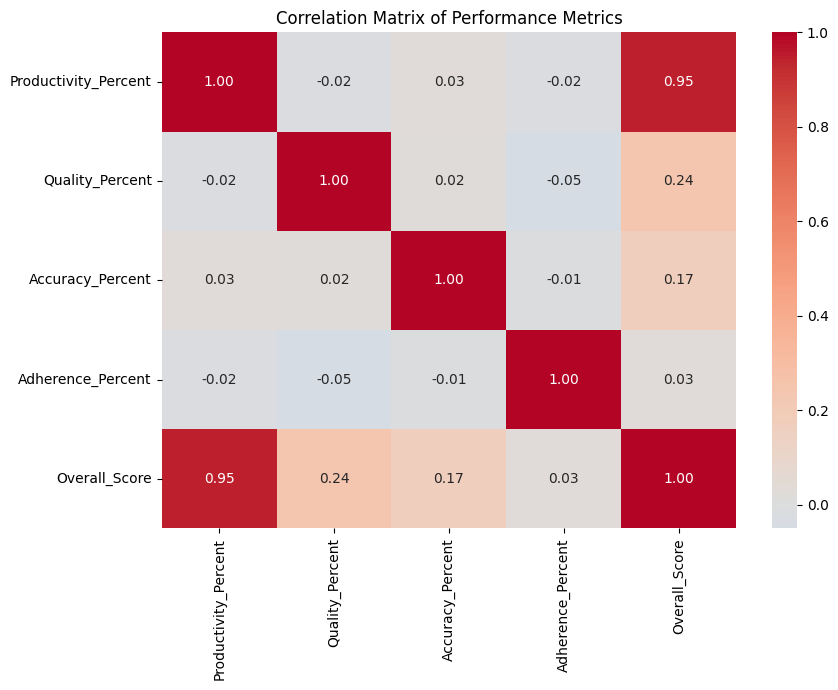

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Performance Metrics")

plt.tight_layout()

plt.savefig(
    "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
# Employee-level performance analysis

employee_performance = df.groupby(
    ["Employee_ID", "Employee_Name"]
).agg(
    Average_Productivity=("Productivity_Percent", "mean"),
    Average_Quality=("Quality_Percent", "mean"),
    Average_Accuracy=("Accuracy_Percent", "mean"),
    Average_Adherence=("Adherence_Percent", "mean"),
    Average_Overall_Score=("Overall_Score", "mean"),
    Total_Cases=("Cases_Reviewed", "sum"),
    Total_Errors=("Errors", "sum"),
    Total_Overtime=("Overtime_Hours", "sum")
).round(2)

employee_performance.head(10)

,,Average_Productivity,Average_Quality,Average_Accuracy,Average_Adherence,Average_Overall_Score,Total_Cases,Total_Errors,Total_Overtime
Employee_ID,Employee_Name,,,,,,,,
EMP001,Employee 001,95.50,93.25,94.58,95.58,94.75,5156,347,50
EMP002,Employee 002,102.67,93.25,94.33,96.08,97.50,5543,366,67
EMP003,Employee 003,98.75,94.00,93.42,95.08,96.00,5341,333,51
EMP004,Employee 004,98.00,93.58,93.42,96.50,95.58,5293,334,62
EMP005,Employee 005,109.67,93.42,93.17,95.58,100.17,5915,399,50
EMP006,Employee 006,99.17,91.92,93.58,95.00,95.33,5351,434,64
EMP007,Employee 007,97.00,92.25,93.42,96.08,94.75,5240,408,62
EMP008,Employee 008,97.33,93.67,93.83,95.08,95.42,5261,338,49
EMP009,Employee 009,104.08,92.00,93.83,95.25,97.50,5620,438,62


In [28]:
top_employees = employee_performance.sort_values(
    "Average_Overall_Score",
    ascending=False
).head(10)

top_employees

,,Average_Productivity,Average_Quality,Average_Accuracy,Average_Adherence,Average_Overall_Score,Total_Cases,Total_Errors,Total_Overtime
Employee_ID,Employee_Name,,,,,,,,
EMP073,Employee 073,109.50,93.83,95.58,93.58,100.33,5921,362,50
EMP005,Employee 005,109.67,93.42,93.17,95.58,100.17,5915,399,50
EMP058,Employee 058,108.17,92.92,94.92,94.33,99.67,5839,415,41
EMP036,Employee 036,110.75,90.75,93.17,95.50,99.67,5978,570,83
EMP039,Employee 039,108.50,92.92,92.42,95.17,99.33,5855,420,47
EMP088,Employee 088,105.83,94.83,94.42,95.83,99.33,5721,297,46
EMP085,Employee 085,107.92,92.08,93.92,94.25,99.17,5826,457,66
EMP054,Employee 054,107.33,92.58,94.17,93.75,99.00,5801,435,58
EMP049,Employee 049,107.83,91.67,93.83,95.33,99.00,5833,487,52


In [29]:
bottom_employees = employee_performance.sort_values(
    "Average_Overall_Score",
    ascending=True
).head(10)

bottom_employees

,,Average_Productivity,Average_Quality,Average_Accuracy,Average_Adherence,Average_Overall_Score,Total_Cases,Total_Errors,Total_Overtime
Employee_ID,Employee_Name,,,,,,,,
EMP091,Employee 091,90.83,90.67,93.00,95.33,91.58,4913,455,64
EMP090,Employee 090,91.08,92.00,93.75,95.67,92.42,4918,389,56
EMP047,Employee 047,91.83,94.00,90.92,94.92,92.75,4961,303,56
EMP038,Employee 038,91.83,92.67,94.50,94.67,92.92,4958,375,72
EMP024,Employee 024,92.67,92.67,93.58,94.92,93.08,5003,371,41
EMP081,Employee 081,93.50,91.42,94.50,94.67,93.17,5054,446,46
EMP062,Employee 062,94.58,91.25,93.08,95.75,93.33,5107,465,30
EMP011,Employee 011,92.17,92.75,96.42,93.67,93.33,4980,359,67
EMP028,Employee 028,94.67,91.25,93.92,95.25,93.50,5111,437,40


In [30]:
employee_analysis = employee_performance.copy()

employee_analysis["Error_Rate_Percent"] = (
    employee_analysis["Total_Errors"] /
    employee_analysis["Total_Cases"] * 100
).round(2)

employee_analysis.head(10)

,,Average_Productivity,Average_Quality,Average_Accuracy,Average_Adherence,Average_Overall_Score,Total_Cases,Total_Errors,Total_Overtime,Error_Rate_Percent
Employee_ID,Employee_Name,,,,,,,,,
EMP001,Employee 001,95.50,93.25,94.58,95.58,94.75,5156,347,50,6.73
EMP002,Employee 002,102.67,93.25,94.33,96.08,97.50,5543,366,67,6.60
EMP003,Employee 003,98.75,94.00,93.42,95.08,96.00,5341,333,51,6.23
EMP004,Employee 004,98.00,93.58,93.42,96.50,95.58,5293,334,62,6.31
EMP005,Employee 005,109.67,93.42,93.17,95.58,100.17,5915,399,50,6.75
EMP006,Employee 006,99.17,91.92,93.58,95.00,95.33,5351,434,64,8.11
EMP007,Employee 007,97.00,92.25,93.42,96.08,94.75,5240,408,62,7.79
EMP008,Employee 008,97.33,93.67,93.83,95.08,95.42,5261,338,49,6.42
EMP009,Employee 009,104.08,92.00,93.83,95.25,97.50,5620,438,62,7.79


In [31]:
highest_error_employees = employee_analysis.sort_values(
    "Error_Rate_Percent",
    ascending=False
).head(10)

highest_error_employees

,,Average_Productivity,Average_Quality,Average_Accuracy,Average_Adherence,Average_Overall_Score,Total_Cases,Total_Errors,Total_Overtime,Error_Rate_Percent
Employee_ID,Employee_Name,,,,,,,,,
EMP020,Employee 020,102.25,88.50,95.75,95.75,96.33,5530,634,65,11.46
EMP051,Employee 051,102.75,89.33,94.58,95.08,96.25,5536,582,51,10.51
EMP099,Employee 099,104.25,89.92,93.08,94.75,96.75,5631,577,59,10.25
EMP084,Employee 084,103.08,90.00,95.67,93.08,96.83,5568,564,63,10.13
EMP086,Employee 086,102.33,90.33,94.08,94.75,96.25,5532,552,80,9.98
EMP069,Employee 069,105.00,90.42,92.58,95.33,97.17,5672,550,75,9.70
EMP036,Employee 036,110.75,90.75,93.17,95.50,99.67,5978,570,83,9.53
EMP061,Employee 061,103.17,90.92,93.75,94.33,96.67,5570,520,56,9.34
EMP091,Employee 091,90.83,90.67,93.00,95.33,91.58,4913,455,64,9.26


In [32]:
lowest_error_employees = employee_analysis.sort_values(
    "Error_Rate_Percent",
    ascending=True
).head(10)

lowest_error_employees

,,Average_Productivity,Average_Quality,Average_Accuracy,Average_Adherence,Average_Overall_Score,Total_Cases,Total_Errors,Total_Overtime,Error_Rate_Percent
Employee_ID,Employee_Name,,,,,,,,,
EMP059,Employee 059,97.83,94.75,91.67,95.17,95.50,5284,263,45,4.98
EMP068,Employee 068,98.75,94.92,93.42,96.42,96.33,5336,270,69,5.06
EMP088,Employee 088,105.83,94.83,94.42,95.83,99.33,5721,297,46,5.19
EMP043,Employee 043,104.08,94.83,94.42,93.83,98.50,5621,296,64,5.27
EMP017,Employee 017,97.33,94.67,95.50,94.25,95.83,5262,284,57,5.40
EMP027,Employee 027,104.58,94.42,92.50,95.25,98.17,5644,307,50,5.44
EMP072,Employee 072,104.42,94.33,93.67,95.25,98.33,5641,308,64,5.46
EMP063,Employee 063,100.33,94.58,94.33,94.33,96.92,5417,303,57,5.59
EMP048,Employee 048,100.08,94.08,93.75,93.33,96.42,5401,313,56,5.80


In [33]:
top_error_rate = employee_analysis.sort_values(
    "Error_Rate_Percent",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_error_rate["Employee_ID"],
    top_error_rate["Error_Rate_Percent"]
)

plt.title("Top 10 Employees by Error Rate")
plt.xlabel("Employee ID")
plt.ylabel("Error Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "top_10_employee_error_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

KeyError: 'Employee_ID'

<Figure size 1000x600 with 0 Axes>

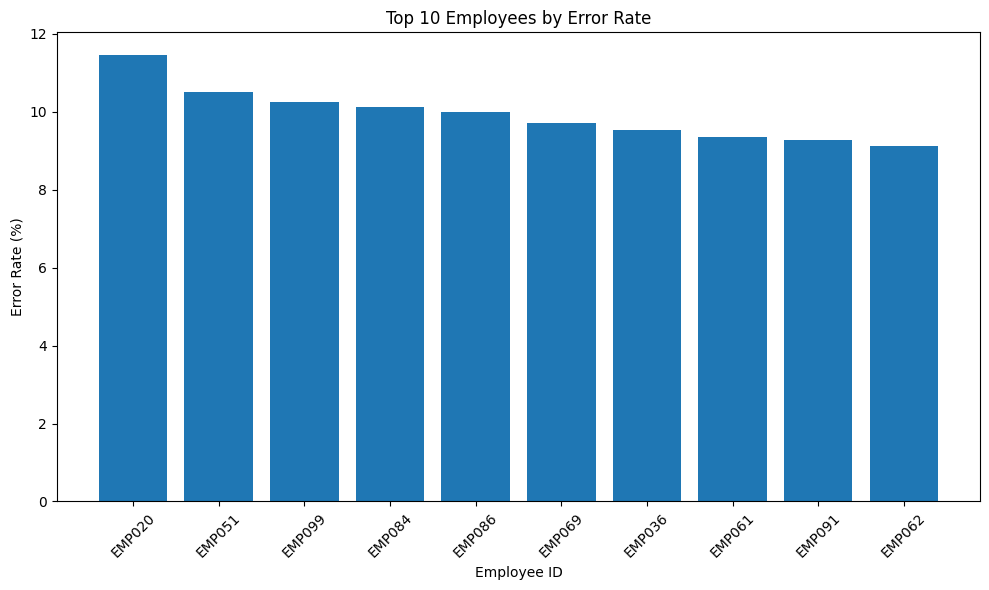

In [34]:
top_error_rate = employee_analysis.sort_values(
    "Error_Rate_Percent",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_error_rate.index.get_level_values("Employee_ID"),
    top_error_rate["Error_Rate_Percent"]
)

plt.title("Top 10 Employees by Error Rate")
plt.xlabel("Employee ID")
plt.ylabel("Error Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "top_10_employee_error_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
overtime_performance_corr = employee_analysis[
    [
        "Total_Overtime",
        "Average_Productivity",
        "Average_Quality",
        "Average_Overall_Score",
        "Error_Rate_Percent"
    ]
].corr().round(2)

overtime_performance_corr

,Total_Overtime,Average_Productivity,Average_Quality,Average_Overall_Score,Error_Rate_Percent
Total_Overtime,1.00,0.10,-0.11,0.07,0.11
Average_Productivity,0.10,1.00,-0.08,0.97,0.08
Average_Quality,-0.11,-0.08,1.00,0.13,-0.99
Average_Overall_Score,0.07,0.97,0.13,1.00,-0.13
Error_Rate_Percent,0.11,0.08,-0.99,-0.13,1.00


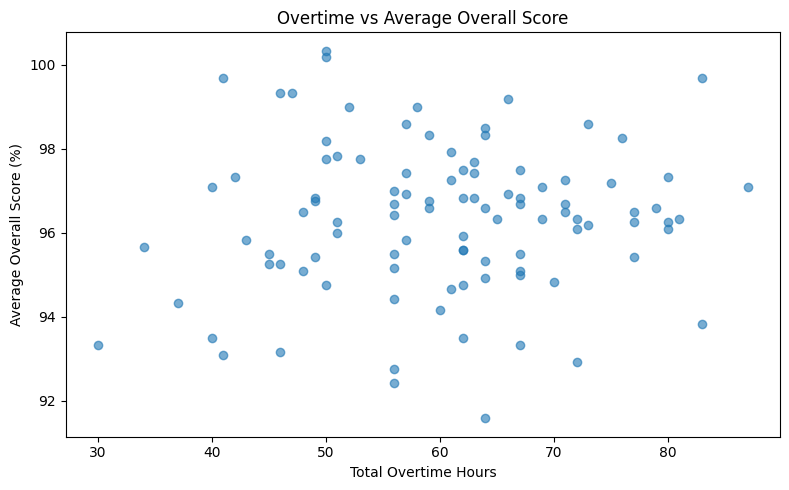

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    employee_analysis["Total_Overtime"],
    employee_analysis["Average_Overall_Score"],
    alpha=0.6
)

plt.title("Overtime vs Average Overall Score")
plt.xlabel("Total Overtime Hours")
plt.ylabel("Average Overall Score (%)")

plt.tight_layout()

plt.savefig(
    "overtime_vs_overall_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
role_performance = df.groupby("Role").agg(
    Average_Productivity=("Productivity_Percent", "mean"),
    Average_Quality=("Quality_Percent", "mean"),
    Average_Accuracy=("Accuracy_Percent", "mean"),
    Average_Adherence=("Adherence_Percent", "mean"),
    Average_Overall_Score=("Overall_Score", "mean"),
    Total_Cases=("Cases_Reviewed", "sum"),
    Total_Errors=("Errors", "sum"),
    Total_Overtime=("Overtime_Hours", "sum")
).round(2)

role_performance

,Average_Productivity,Average_Quality,Average_Accuracy,Average_Adherence,Average_Overall_Score,Total_Cases,Total_Errors,Total_Overtime
Role,,,,,,,,
Content Reviewer,100.79,92.41,93.93,94.97,96.35,544281,41420,6019


In [38]:
team_status = pd.crosstab(
    df["Team"],
    df["Performance_Status"],
    normalize="index"
).mul(100).round(2)

team_status

Performance_Status,Below Target,Exceeded Target,Met Target
Team,,,
Team A,19.17,27.92,52.92
Team B,18.75,33.33,47.92
Team C,12.50,29.58,57.92
Team D,15.42,31.25,53.33
Team E,15.00,30.42,54.58


In [39]:
status_error_analysis = df.groupby("Performance_Status").agg(
    Total_Cases=("Cases_Reviewed", "sum"),
    Total_Errors=("Errors", "sum"),
    Average_Quality=("Quality_Percent", "mean"),
    Average_Productivity=("Productivity_Percent", "mean"),
    Average_Overall_Score=("Overall_Score", "mean")
).round(2)

status_error_analysis["Error_Rate_Percent"] = (
    status_error_analysis["Total_Errors"] /
    status_error_analysis["Total_Cases"] * 100
).round(2)

status_error_analysis

,Total_Cases,Total_Errors,Average_Quality,Average_Productivity,Average_Overall_Score,Error_Rate_Percent
Performance_Status,,,,,,
Below Target,72130,6991,90.41,82.60,88.27,9.69
Exceeded Target,190778,12571,93.48,115.83,102.82,6.59
Met Target,281373,21858,92.40,97.70,95.10,7.77


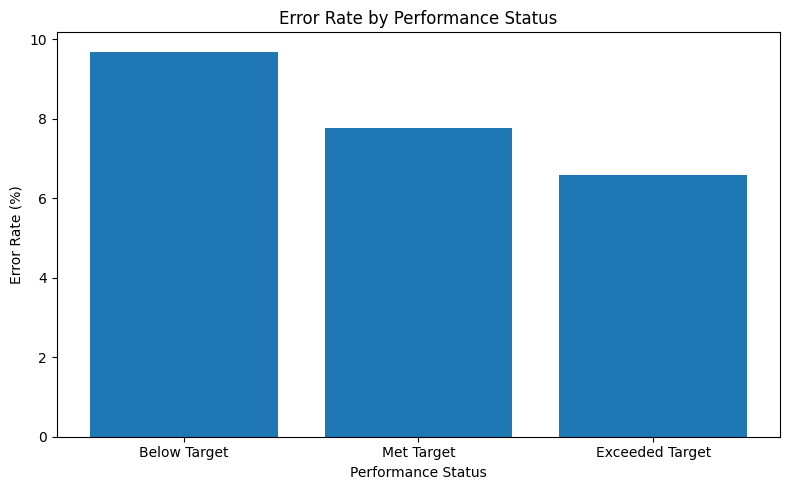

In [40]:
status_error_chart = status_error_analysis.sort_values(
    "Error_Rate_Percent",
    ascending=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    status_error_chart.index,
    status_error_chart["Error_Rate_Percent"]
)

plt.title("Error Rate by Performance Status")
plt.xlabel("Performance Status")
plt.ylabel("Error Rate (%)")

plt.tight_layout()

plt.savefig(
    "error_rate_by_performance_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
attendance_analysis = df.groupby("Employee_ID").agg(
    Total_Present_Days=("Present_Days", "sum"),
    Total_Absent_Days=("Absent_Days", "sum"),
    Total_Leave_Days=("Leave_Days", "sum"),
    Average_Productivity=("Productivity_Percent", "mean"),
    Average_Overall_Score=("Overall_Score", "mean"),
    Total_Cases=("Cases_Reviewed", "sum"),
    Total_Errors=("Errors", "sum")
).round(2)

attendance_analysis["Error_Rate_Percent"] = (
    attendance_analysis["Total_Errors"] /
    attendance_analysis["Total_Cases"] * 100
).round(2)

attendance_analysis.head(10)

,Total_Present_Days,Total_Absent_Days,Total_Leave_Days,Average_Productivity,Average_Overall_Score,Total_Cases,Total_Errors,Error_Rate_Percent
Employee_ID,,,,,,,,
EMP001,42,11,7,95.50,94.75,5156,347,6.73
EMP002,47,9,4,102.67,97.50,5543,366,6.60
EMP003,43,6,11,98.75,96.00,5341,333,6.23
EMP004,45,8,7,98.00,95.58,5293,334,6.31
EMP005,47,6,7,109.67,100.17,5915,399,6.75
EMP006,51,4,5,99.17,95.33,5351,434,8.11
EMP007,49,6,5,97.00,94.75,5240,408,7.79
EMP008,45,8,7,97.33,95.42,5261,338,6.42
EMP009,48,5,7,104.08,97.50,5620,438,7.79


In [42]:
attendance_correlation = attendance_analysis[
    [
        "Total_Present_Days",
        "Total_Absent_Days",
        "Total_Leave_Days",
        "Average_Productivity",
        "Average_Overall_Score",
        "Error_Rate_Percent"
    ]
].corr().round(2)

attendance_correlation

,Total_Present_Days,Total_Absent_Days,Total_Leave_Days,Average_Productivity,Average_Overall_Score,Error_Rate_Percent
Total_Present_Days,1.00,-0.60,-0.69,-0.04,-0.07,0.12
Total_Absent_Days,-0.60,1.00,-0.17,-0.15,-0.13,-0.15
Total_Leave_Days,-0.69,-0.17,1.00,0.18,0.20,-0.02
Average_Productivity,-0.04,-0.15,0.18,1.00,0.97,0.08
Average_Overall_Score,-0.07,-0.13,0.20,0.97,1.00,-0.13
Error_Rate_Percent,0.12,-0.15,-0.02,0.08,-0.13,1.00


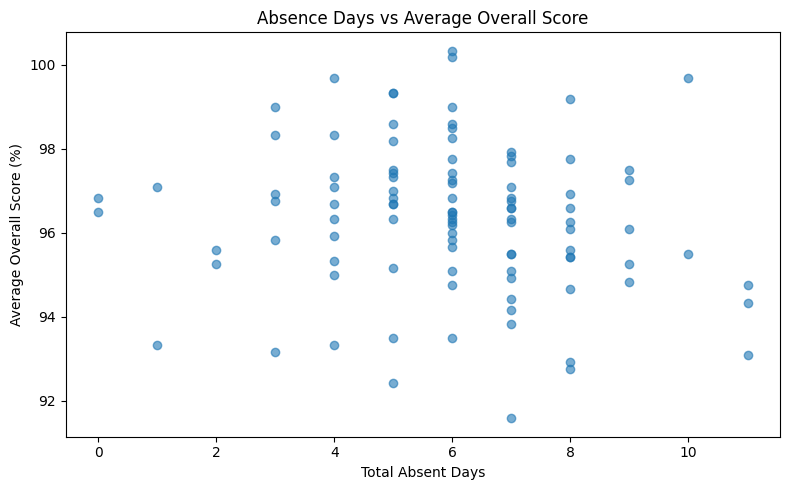

In [43]:
plt.figure(figsize=(8, 5))

plt.scatter(
    attendance_analysis["Total_Absent_Days"],
    attendance_analysis["Average_Overall_Score"],
    alpha=0.6
)

plt.title("Absence Days vs Average Overall Score")
plt.xlabel("Total Absent Days")
plt.ylabel("Average Overall Score (%)")

plt.tight_layout()

plt.savefig(
    "absence_vs_overall_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
cases_performance_corr = employee_analysis[
    [
        "Total_Cases",
        "Average_Productivity",
        "Average_Quality",
        "Average_Overall_Score",
        "Error_Rate_Percent"
    ]
].corr().round(2)

cases_performance_corr

,Total_Cases,Average_Productivity,Average_Quality,Average_Overall_Score,Error_Rate_Percent
Total_Cases,1.00,1.00,-0.07,0.97,0.08
Average_Productivity,1.00,1.00,-0.08,0.97,0.08
Average_Quality,-0.07,-0.08,1.00,0.13,-0.99
Average_Overall_Score,0.97,0.97,0.13,1.00,-0.13
Error_Rate_Percent,0.08,0.08,-0.99,-0.13,1.00


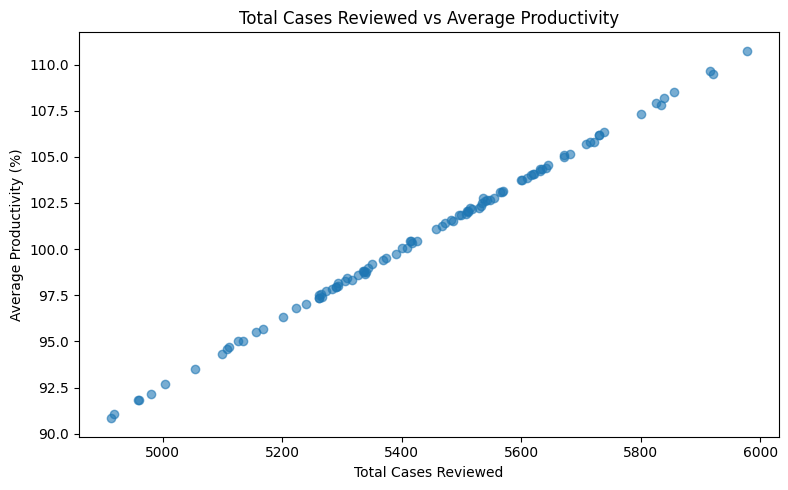

In [45]:
plt.figure(figsize=(8, 5))

plt.scatter(
    employee_analysis["Total_Cases"],
    employee_analysis["Average_Productivity"],
    alpha=0.6
)

plt.title("Total Cases Reviewed vs Average Productivity")
plt.xlabel("Total Cases Reviewed")
plt.ylabel("Average Productivity (%)")

plt.tight_layout()

plt.savefig(
    "cases_vs_productivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
final_summary = pd.DataFrame({
    "Metric": [
        "Average Productivity",
        "Average Quality",
        "Average Accuracy",
        "Average Adherence",
        "Average Overall Score",
        "Total Cases Reviewed",
        "Total Errors",
        "Total Overtime Hours",
        "Overall Error Rate",
        "Met or Exceeded Target (%)"
    ],
    "Value": [
        round(df["Productivity_Percent"].mean(), 2),
        round(df["Quality_Percent"].mean(), 2),
        round(df["Accuracy_Percent"].mean(), 2),
        round(df["Adherence_Percent"].mean(), 2),
        round(df["Overall_Score"].mean(), 2),
        df["Cases_Reviewed"].sum(),
        df["Errors"].sum(),
        df["Overtime_Hours"].sum(),
        round(
            df["Errors"].sum() /
            df["Cases_Reviewed"].sum() * 100,
            2
        ),
        round(
            df["Performance_Status"]
            .isin(["Met Target", "Exceeded Target"])
            .mean() * 100,
            2
        )
    ]
})

final_summary

,Metric,Value
0,Average Productivity,100.79
1,Average Quality,92.41
2,Average Accuracy,93.93
3,Average Adherence,94.97
4,Average Overall Score,96.35
5,Total Cases Reviewed,544281.00
6,Total Errors,41420.00
7,Total Overtime Hours,6019.00
8,Overall Error Rate,7.61
9,Met or Exceeded Target (%),83.83


In [47]:
kpi_values = {
    "Average Productivity": df["Productivity_Percent"].mean(),
    "Average Quality": df["Quality_Percent"].mean(),
    "Average Accuracy": df["Accuracy_Percent"].mean(),
    "Average Adherence": df["Adherence_Percent"].mean(),
    "Average Overall Score": df["Overall_Score"].mean(),
    "Overall Error Rate": (
        df["Errors"].sum() /
        df["Cases_Reviewed"].sum() * 100
    )
}

kpi_values

{'Average Productivity': np.float64(100.7875),
 'Average Quality': np.float64(92.40833333333333),
 'Average Accuracy': np.float64(93.9325),
 'Average Adherence': np.float64(94.9725),
 'Average Overall Score': np.float64(96.34666666666666),
 'Overall Error Rate': np.float64(7.6100396670102395)}

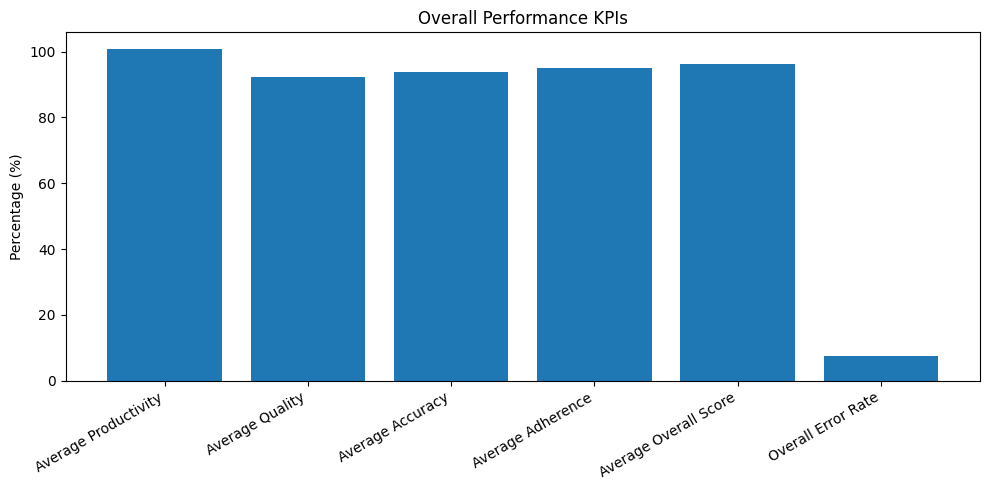

In [48]:
plt.figure(figsize=(10, 5))

plt.bar(
    kpi_values.keys(),
    kpi_values.values()
)

plt.title("Overall Performance KPIs")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.savefig(
    "overall_performance_kpis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

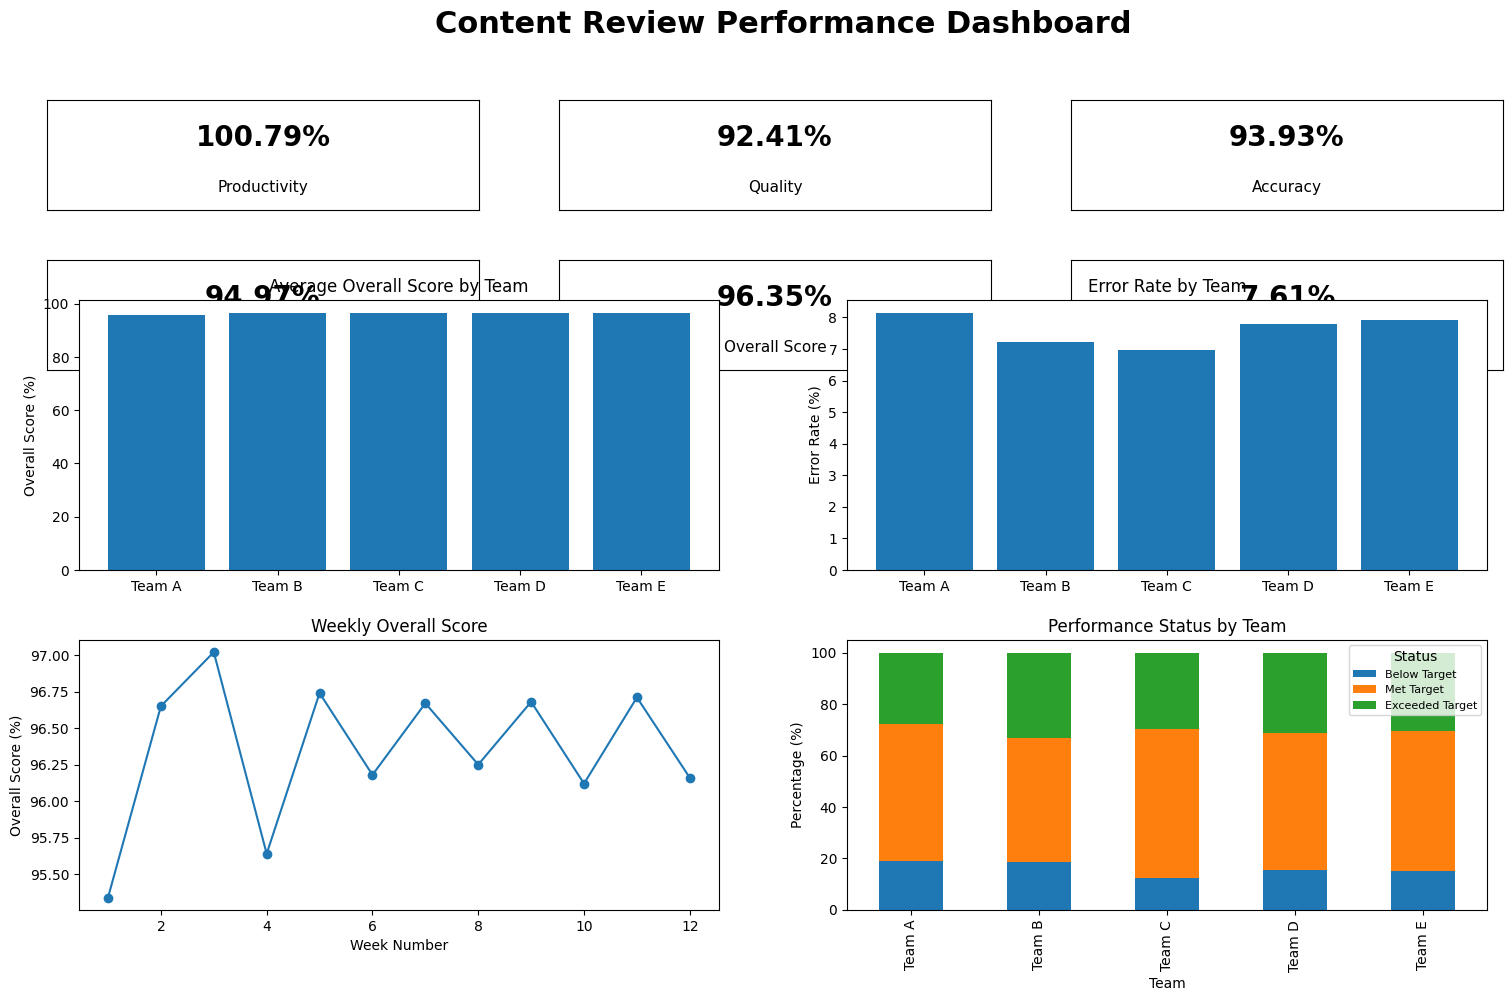

In [49]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(16, 10))

# =========================
# Dashboard Title
# =========================

fig.suptitle(
    "Content Review Performance Dashboard",
    fontsize=22,
    fontweight="bold",
    y=0.98
)

# =========================
# KPI Cards
# =========================

kpis = [
    ("Productivity", 100.79, "%"),
    ("Quality", 92.41, "%"),
    ("Accuracy", 93.93, "%"),
    ("Adherence", 94.97, "%"),
    ("Overall Score", 96.35, "%"),
    ("Error Rate", 7.61, "%")
]

for i, (name, value, suffix) in enumerate(kpis):

    ax = fig.add_axes([
        0.04 + (i % 3) * 0.32,
        0.78 - (i // 3) * 0.16,
        0.27,
        0.11
    ])

    ax.text(
        0.5,
        0.65,
        f"{value:.2f}{suffix}",
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.20,
        name,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.set_xticks([])
    ax.set_yticks([])

# =========================
# Team Overall Score
# =========================

ax1 = fig.add_axes([0.06, 0.42, 0.40, 0.27])

ax1.bar(
    team_performance.index,
    team_performance["Average_Overall_Score"]
)

ax1.set_title("Average Overall Score by Team")
ax1.set_ylabel("Overall Score (%)")

# =========================
# Team Error Rate
# =========================

ax2 = fig.add_axes([0.54, 0.42, 0.40, 0.27])

ax2.bar(
    team_analysis.index,
    team_analysis["Error_Rate_Percent"]
)

ax2.set_title("Error Rate by Team")
ax2.set_ylabel("Error Rate (%)")

# =========================
# Weekly Overall Score
# =========================

ax3 = fig.add_axes([0.06, 0.08, 0.40, 0.27])

ax3.plot(
    weekly_performance.index,
    weekly_performance["Average_Overall_Score"],
    marker="o"
)

ax3.set_title("Weekly Overall Score")
ax3.set_xlabel("Week Number")
ax3.set_ylabel("Overall Score (%)")

# =========================
# Performance Status
# =========================

ax4 = fig.add_axes([0.54, 0.08, 0.40, 0.27])

status_chart = pd.crosstab(
    df["Team"],
    df["Performance_Status"],
    normalize="index"
).mul(100)

status_chart = status_chart[
    ["Below Target", "Met Target", "Exceeded Target"]
]

status_chart.plot(
    kind="bar",
    stacked=True,
    ax=ax4
)

ax4.set_title("Performance Status by Team")
ax4.set_xlabel("Team")
ax4.set_ylabel("Percentage (%)")
ax4.legend(
    title="Status",
    fontsize=8
)

plt.savefig(
    "wipro_content_review_dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()